# 01 — Configuration & Data Loading

**Purpose:** Load and inspect the CAT411 configuration file, parse ShakeMap and NBI data,
and classify bridges into Hazus categories.

## Input Files

| File | Format | Description |
|------|--------|-------------|
| `config.yaml` | YAML | Analysis configuration (region, IM source, interpolation, etc.) |
| `data/grid.xml` | XML (USGS ShakeMap) | Regular grid of ground motion values (PGA, Sa 0.3s/1.0s/3.0s in g) |
| `data/CA24.txt` | Fixed-width text (FHWA NBI) | California bridge inventory (~25,000 bridges statewide) |

## Outputs (in-memory)

| Object | Type | Description |
|--------|------|-------------|
| `cfg` | `AnalysisConfig` | Parsed config with region, IM source, filters, etc. |
| `grid` | `pd.DataFrame` (215,642 × 9) | ShakeMap grid; columns: LON, LAT, PGA, PGV, MMI, PSA03, PSA10, PSA30, SVEL |
| `nbi` | `pd.DataFrame` (~2,953 × 15) | Classified bridges; includes `hwb_class` column (HWB1–HWB28) |

## Expected Plots

- **Bridge location scatter map** — bridges colored by HWB class, epicenter marked with red star

**Key concepts:** Configuration-driven analysis, ShakeMap XML parsing,
NBI fixed-width parsing, Hazus bridge classification (HWB1–HWB28)

## Imports & Setup

In [1]:
import sys
from pathlib import Path

# Add project root to path so we can import src modules
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx

from src.config import load_config, print_config_summary
from src.data_loader import load_shakemap, load_nbi, classify_nbi_to_hazus

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
%matplotlib inline

### Data Vintage Note
This tutorial uses the **2024 NBI** (`CA24.txt`) as a proxy for the 1994 Northridge bridge inventory. The 2024 dataset contains ~2,953 bridges in the study region vs ~1,600 in 1994. Bridge count, retrofit status, and HWB class distribution differ from the actual 1994 stock.

## Step 1: Load Configuration

**Input:** `config.yaml` (YAML) — 10 sections controlling region bounds, bridge filters, IM source, interpolation, GMPE scenario, fragility overrides, calibration, and analysis parameters.

**Output:** `AnalysisConfig` dataclass with properties: `region` (bounding box dict), `im_source` ("shakemap"/"gmpe"), `im_type` ("SA10"), `interpolation_method` ("nearest"), `seed` (42), etc.

In [2]:
cfg = load_config(PROJECT_ROOT / "config.yaml")
print_config_summary(cfg)

ANALYSIS CONFIGURATION
  Region: lat[33.8, 34.6] lon[-118.9, -118.0]
  IM Source: shakemap
  IM Type: SA10 (ShakeMap column: PSA10)
  Interpolation: nearest
  Realizations: 50, Events: 50, Seed: 42



In [3]:
# Inspect individual config fields
print(f"Region:        {cfg.region}")
print(f"IM source:     {cfg.im_source}")
print(f"IM type:       {cfg.im_type}")
print(f"Interpolation: {cfg.interpolation_method}")
print(f"Seed:          {cfg.seed}")

Region:        {'lat_min': 33.8, 'lat_max': 34.6, 'lon_min': -118.9, 'lon_max': -118.0}
IM source:     shakemap
IM type:       SA10
Interpolation: nearest
Seed:          42


## Step 2: Parse ShakeMap Grid

**Input:** `data/grid.xml` (XML, ~40 MB) — USGS ShakeMap for event ci3144585 (Northridge 1994 Mw 6.7). Contains `<grid_data>` with columns: LON, LAT, PGA, PGV, MMI, PSA03, PSA10, PSA30, SVEL. Raw values in %g are auto-converted to g.

**Output:** `grid` DataFrame (215,642 rows × 9 columns). Also stores event metadata in `grid.attrs` (event_id, magnitude, lat, lon, event_description).

**Expected display:** Grid shape, column names, IM range statistics (min/max/mean for PGA, PSA03, PSA10, PSA30).

In [4]:
grid = load_shakemap(PROJECT_ROOT / "data" / "grid.xml")

print(f"Grid shape:    {grid.shape}")
print(f"Columns:       {list(grid.columns)}")
print(f"\nEvent info:")
for key in ["event_id", "magnitude", "lat", "lon", "event_description"]:
    print(f"  {key}: {grid.attrs.get(key, 'N/A')}")

Grid shape:    (215642, 9)
Columns:       ['LON', 'LAT', 'MMI', 'PGA', 'PGV', 'PSA03', 'PSA10', 'PSA30', 'SVEL']

Event info:
  event_id: ci3144585
  magnitude: 0.0
  lat: 0.0
  lon: 0.0
  event_description: 


In [5]:
# Ground motion statistics
print("ShakeMap IM ranges (in g):")
for col in ["PGA", "PSA03", "PSA10", "PSA30"]:
    if col in grid.columns:
        print(f"  {col:6s}: min={grid[col].min():.4f}, "
              f"max={grid[col].max():.4f}, mean={grid[col].mean():.4f}")

grid.head(5)

ShakeMap IM ranges (in g):
  PGA   : min=0.0004, max=0.8684, mean=0.0158
  PSA03 : min=0.0011, max=1.7050, mean=0.0335
  PSA10 : min=0.0025, max=1.2610, mean=0.0228
  PSA30 : min=0.0009, max=0.3346, mean=0.0049


,LON,LAT,MMI,PGA,PGV,PSA03,PSA10,PSA30,SVEL
0,-122.6167,37.7167,3.0,0.000615,0.3533,0.001632,0.004219,0.001356,600.0
1,-122.6000,37.7167,3.0,0.000621,0.3549,0.001646,0.004237,0.001360,600.0
2,-122.5833,37.7167,3.0,0.000628,0.3565,0.001661,0.004256,0.001363,600.0
3,-122.5667,37.7167,3.0,0.000634,0.3581,0.001675,0.004275,0.001367,600.0
4,-122.5500,37.7167,3.0,0.000640,0.3597,0.001690,0.004293,0.001371,600.0


## Step 3: Parse NBI Bridge Inventory

**Input:** `data/CA24.txt` (fixed-width, pipe-delimited FHWA NBI format) — California bridge inventory. Filtered by `cfg.region` bounding box (lat 33.8–34.6, lon -118.9 to -118.0).

**Output:** `nbi` DataFrame (~2,953 rows × 14 columns): structure_number, state, county, latitude, longitude, year_built, material_code, material, design_code, design_type, num_spans, structure_length_m, deck_width_m, condition_rating.

**Expected display:** Bridge count, column list, first 5 rows.

In [6]:
nbi = load_nbi(
    PROJECT_ROOT / "data" / "CA24.txt",
    northridge_bbox=cfg.region,
)

print(f"Bridges in region: {len(nbi)}")
print(f"Columns: {list(nbi.columns)}")
nbi.head(5)

Bridges in region: 2953
Columns: ['structure_number', 'state', 'county', 'latitude', 'longitude', 'year_built', 'material_code', 'material', 'design_code', 'design_type', 'num_spans', 'structure_length_m', 'deck_width_m', 'condition_rating']


,structure_number,state,county,latitude,longitude,year_built,material_code,material,design_code,design_type,num_spans,structure_length_m,deck_width_m,condition_rating
0,52 0036,06,111,34.400708,-118.827000,1997,6,prestressed_concrete,6,other,2,45.4,23.8,5.0
1,52 0037,06,111,34.408781,-118.787797,1940,2,concrete,6,other,17,259.2,25.0,5.0
2,52 0046,06,111,34.143069,-118.849192,1968,2,concrete,5,other,2,10.1,32.9,NaN
3,52 0237,06,111,34.177492,-118.876247,1962,2,concrete,6,other,4,52.4,37.2,5.0
4,52 0268E,06,111,34.157158,-118.825219,1964,5,prestressed_concrete,5,other,4,95.3,28.7,7.0


## Step 4: Classify Bridges to Hazus HWB Classes

**Input:** `nbi` DataFrame with material, design_type, num_spans, year_built columns.

**Output:** Same DataFrame with added `hwb_class` column (string, e.g. "HWB5", "HWB17"). Classification based on material × design × span × era rules from Hazus 6.1 Table 7.9.

**Expected display:** HWB class value counts (bar of 13 classes), first 10 rows with classification details.

In [7]:
nbi = classify_nbi_to_hazus(
    nbi,
    hwb_filter=cfg.hwb_filter,
    design_era_filter=cfg.design_era,
    material_filter=cfg.material_filter,
)

print(f"Classified bridges: {len(nbi)}")
print(f"\nHWB class distribution:")
display(nbi["hwb_class"].value_counts().sort_index())

Classified bridges: 2953

HWB class distribution:


hwb_class
HWB1      165
HWB10      23
HWB15      73
HWB16      21
HWB17    1008
HWB2      140
HWB28     107
HWB3      665
HWB4      264
HWB5      116
HWB6       14
HWB7      285
HWB8       72
Name: count, dtype: int64

In [8]:
# Inspect first 10 classified bridges
display(nbi[["structure_number", "latitude", "longitude",
             "material", "design_type", "num_spans",
             "year_built", "hwb_class"]].head(10))

,structure_number,latitude,longitude,material,design_type,num_spans,year_built,hwb_class
0,52 0036,34.400708,-118.827000,prestressed_concrete,other,2,1997,HWB17
1,52 0037,34.408781,-118.787797,concrete,other,17,1940,HWB1
2,52 0046,34.143069,-118.849192,concrete,other,2,1968,HWB17
3,52 0237,34.177492,-118.876247,concrete,other,4,1962,HWB17
4,52 0268E,34.157158,-118.825219,prestressed_concrete,other,4,1964,HWB7
5,52 0273,34.166164,-118.837600,concrete,other,3,1966,HWB17
6,52 0274,34.171808,-118.846039,concrete,other,3,1966,HWB17
7,52 0282,34.278867,-118.662336,concrete,other,3,1968,HWB17
8,52 0283,34.268092,-118.635794,concrete,other,2,1968,HWB17
9,52 0299,34.281439,-118.709178,concrete,other,2,1968,HWB17


## Step 5: Bridge Location Map

**Expected plot:** Scatter map with OpenStreetMap basemap. Each point is a bridge, colored by HWB class (tab20 colormap). Red star marks the Northridge epicenter at (-118.537, 34.213).

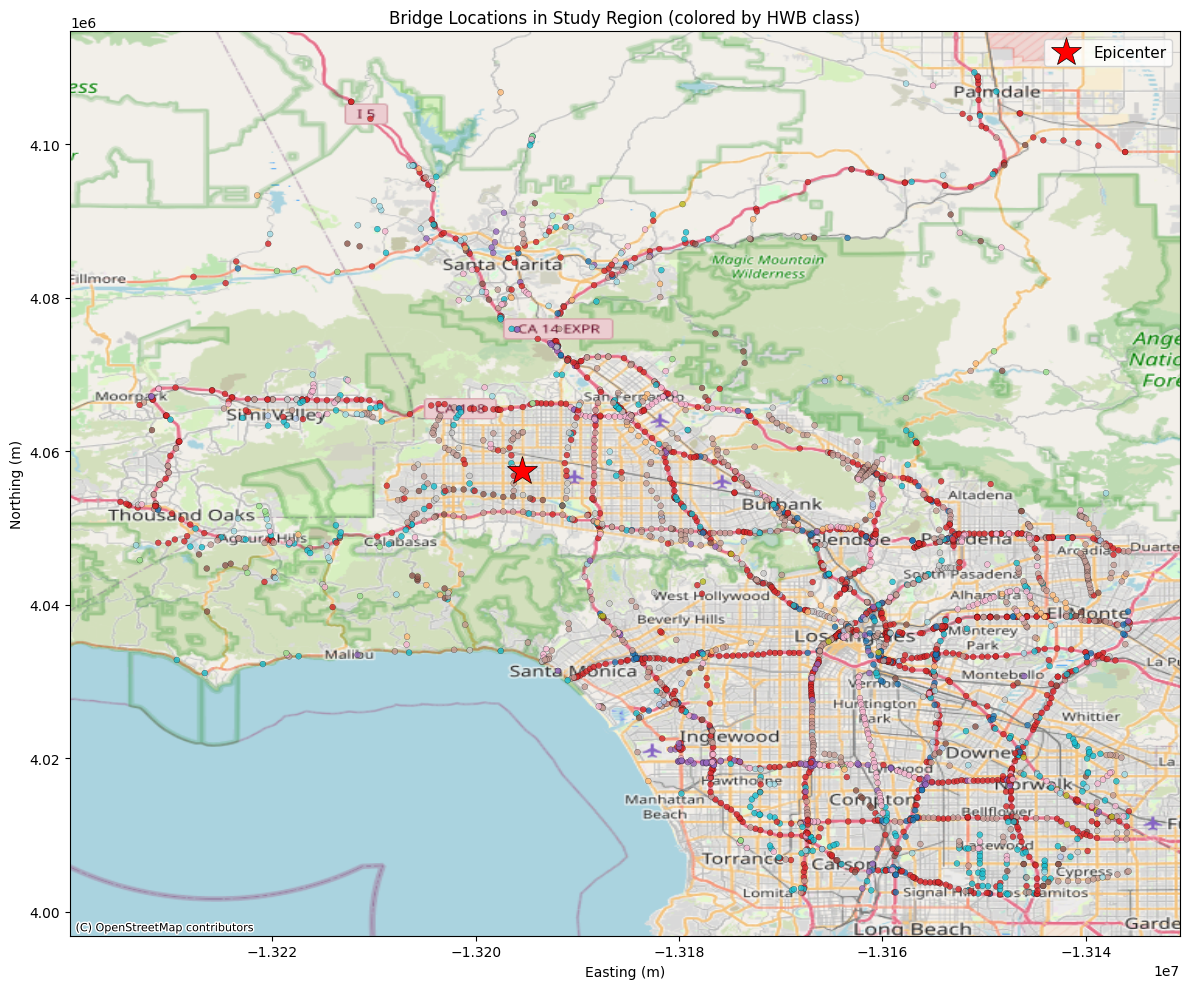

In [9]:
import geopandas as gpd
from shapely.geometry import Point

# Build GeoDataFrame in EPSG:4326 then reproject for basemap
gdf = gpd.GeoDataFrame(
    nbi,
    geometry=[Point(xy) for xy in zip(nbi["longitude"], nbi["latitude"])],
    crs="EPSG:4326",
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

# Color by HWB class
classes = gdf["hwb_class"].astype("category")
scatter = ax.scatter(
    gdf.geometry.x, gdf.geometry.y,
    c=classes.cat.codes, cmap="tab20",
    s=18, alpha=0.8, edgecolors="k", linewidths=0.2,
    zorder=5,
)

# Epicenter in Web Mercator
epi = gpd.GeoDataFrame(
    geometry=[Point(-118.537, 34.213)], crs="EPSG:4326"
).to_crs(epsg=3857)
ax.plot(epi.geometry.x, epi.geometry.y, "r*", markersize=22,
        markeredgecolor="k", markeredgewidth=0.5, label="Epicenter", zorder=6)

# Add basemap
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, zoom=10)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Bridge Locations in Study Region (colored by HWB class)")
ax.legend(loc="upper right", fontsize=11)
plt.tight_layout()
plt.show()

## Summary

In this notebook we:
1. Loaded the analysis configuration from `config.yaml`
2. Parsed the USGS ShakeMap grid (Northridge 1994) with ground motion values
3. Loaded and filtered the NBI bridge inventory to the study region
4. Classified bridges into Hazus HWB classes for fragility analysis
5. Visualized bridge locations

**Next:** [02_hazard_shakemap.ipynb](02_hazard_shakemap.ipynb) — Interpolate ShakeMap IM values to bridge sites